In [1]:
import numpy as np
import rebound as rb
import einsteinpy.symbolic as es    
import scipy as sp 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sympy as sm
import pymcel as pc 
from pymcel import constantes as const




c:\Users\User\OneDrive\Documentos\Relatividad\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


### Sistema de Unidades Geometrizadas

Para simplificar el cálculo numérico de las geodésicas y evitar inconsistencias de escala computacional, adoptamos el sistema de unidades geometrizadas, en el cual se define:

$$G = c = 1$$

Bajo este sistema, la masa $M$ del agujero negro define las escalas fundamentales de longitud y tiempo del problema. La Unidad de Longitud ($UL$) corresponde al radio gravitacional:

$$1 \text{ UL} = \frac{GM}{c^2}$$

De igual manera, la Unidad de Tiempo ($UT$) se define como el tiempo que tarda la luz en recorrer dicha distancia:

$$1 \text{ UT} = \frac{UL}{c} = \frac{GM}{c^3}$$

En estas unidades, el Radio de Schwarzschild para un agujero negro estático viene dado por $R_s = 2M$. 

**Nota computacional:** En los experimentos numéricos de este cuaderno estableceremos $M = 1$. Esto implica que todas las distancias y tiempos en nuestras simulaciones y gráficos estarán expresados implícitamente en múltiplos de la masa del agujero negro (por ejemplo, una coordenada radial $r = 6$ corresponderá a $r = 6M$).

In [2]:
# Definimos unidades basadas en un agujero negro de masa solar (M=1)
c = 1.0  # Velocidad de la luz [6]
G = 1.0  # Constante de gravitación [4]
M = 1.0  # Masa del objeto central

# Unidad de longitud (UL) = Radio gravitacional (GM/c^2)
UL = G * M / c**2 
# Unidad de tiempo (UT) = UL / c
UT = UL / c 

### Geodésicas en el Límite Newtoniano (Campo Débil)

En esta sección se establece el caso base clásico para comparar con las correcciones relativistas. Se implementa la dinámica de partículas en un campo débil bajo unidades geometrizadas.

Para establecer una base comparativa con los efectos relativistas puros, modelamos el comportamiento de las partículas mediante una métrica de campo débil (aproximación Newtoniana). Adoptando la signatura principalmente negativa $(+, -, -, -)$ vista en clase y nuestro sistema de unidades geometrizadas ($G=c=1$), el tensor métrico adopta la forma:

$$ds^2 = \left(1 - \frac{2M}{r}\right)dt^2 - dx^2 - dy^2 - dz^2$$

Utilizando la ecuación de la geodésica $\frac{dU^\mu}{d\tau} + \Gamma^\mu_{\alpha\beta}U^\alpha U^\beta = 0$, deducimos los símbolos de Christoffel relevantes para el movimiento. La evolución temporal del factor de Lorentz de la partícula ($U^t$) queda determinada por:

$$\frac{dU^t}{d\tau} = -\frac{2M U^t}{r^2(r - 2M)} (xU^x + yU^y + zU^z)$$

Mientras que para las componentes espaciales, la ecuación geodésica exacta para esta métrica nos da:

$$\frac{dU^i}{d\tau} = -\frac{M}{r^3}x^i (U^t)^2$$

*(Nota física: En el límite estrictamente clásico donde las velocidades son pequeñas respecto a la luz, el factor de Lorentz $U^t \approx 1$, por lo que recuperamos exactamente la aceleración gravitacional Newtoniana $\frac{d^2x^i}{dt^2} \approx -\frac{M}{r^3}x^i$. Sin embargo, en nuestras simulaciones numéricas conservaremos el término $(U^t)^2$ para que la integración paso a paso respecto al tiempo propio $\tau$ sea matemáticamente coherente con la métrica).*

In [3]:
def edg_newton(tau, Ys, G, M, c):
    """
    Ecuaciones diferenciales para la trayectoria en el límite Newtoniano/Campo Débil.
    Escritas de forma explícita para cada componente (sin factor común).
    Ys contiene: [T, x, y, z, Ut, Ux, Uy, Uz] donde T = c*t
    """
    T, x, y, z, Ut, Ux, Uy, Uz = Ys
    r = np.sqrt(x**2 + y**2 + z**2)
    
    # Evitar división por cero si la partícula cae al centro
    if r < 1e-5:
        return [0]*8
    
    # Derivadas de las coordenadas (Cuadrivelocidad)
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz
    
    # Componente temporal: dUt/dtau (Derivada de U^T)
    denom = (c**2 * r - 2 * G * M) * r**2
    dUt_dtau = -2 * G * M * Ut * (x*Ux + y*Uy + z*Uz) / denom
    
    # Componentes espaciales: dUi/dtau (Derivada de U^i)
    
    dUx_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * x
    dUy_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * y
    dUz_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * z
    
    return [dT_dtau, dx_dtau, dy_dtau, dz_dtau, dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau]

### Determinación de las Condiciones Iniciales y Normalización

Para iniciar la integración numérica de las geodésicas, es fundamental que el vector de estado inicial cumpla con la restricción de normalización de la cuadrivelocidad para partículas con masa. Utilizando la signatura principalmente negativa $(+, -, -, -)$, esta restricción viene definida por el invariante:

$$g_{\mu\nu} U^\mu U^\nu = c^2$$

Dado que conocemos la posición inicial $r_0$ y la velocidad espacial tridimensional respecto al tiempo coordenado $\vec{v} = (v^x, v^y, v^z)$, podemos relacionar las componentes espaciales de la cuadrivelocidad mediante $U^i = U^t \frac{v^i}{c}$ (o simplemente $U^i = U^t v^i$ en unidades relativistas donde $c=1$). 

Sustituyendo esta relación en la condición de normalización para una métrica espacialmente plana:

$$g_{00} (U^t)^2 - \delta_{ij} (U^t v^i)(U^t v^j) = c^2$$

Factorizando $(U^t)^2$ en el miembro izquierdo de la ecuación obtenemos:

$$(U^t)^2 \left( g_{00} - |\vec{v}|^2 \right) = c^2$$

Despejando la componente temporal $U^t$, obtenemos la ecuación que garantiza condiciones iniciales físicamente consistentes y evita soluciones imaginarias bajo el radical:

$$U^t_0 = \frac{c}{\sqrt{g_{00} - |\vec{v}|^2}}$$

En el sistema de unidades canónicas adoptado para la simulación ($c = 1, G = 1$), la expresión final se reduce a:

$$U^t_0 = \frac{1}{\sqrt{g_{00} - |\vec{v}|^2}}$$

In [4]:
t0 = 0.0
# Posición inicial de la partícula en el plano ecuatorial (UL)
x0, y0, z0 = 10.0, 0.0, 0.0
r0 = np.sqrt(x0**2 + y0**2 + z0**2)

# Velocidad inicial de coordenadas dada como fracción de c (adimensional)
vx0, vy0, vz0 = 0.0, 0.25, 0.0 
v_sq = vx0**2 + vy0**2 + vz0**2

# Componentes del tensor métrico inicial
g00 = 1.0 - (2.0 * G * M) / (c**2 * r0)
g11 = g22 = g33 = -1.0  # Espacio tridimensional plano y negativo

# Cálculo de la componente temporal de la cuadrivelocidad (U^T)

Ut0 = c / np.sqrt(g00 - v_sq)

# Transformación a las componentes espaciales de la cuadrivelocidad

Ux0 = vx0 * Ut0
Uy0 = vy0 * Ut0
Uz0 = vz0 * Ut0

# Vector de estado inicial para el integrador (solve_ivp): [T, x, y, z, Ut, Ux, Uy, Uz]

Y0 = [c * t0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]

### Integración Numérica de las Ecuaciones Geodésicas

La evolución del estado de la partícula se obtiene integrando numéricamente un sistema acoplado de ocho ecuaciones diferenciales ordinarias de primer orden, donde la variable independiente es el tiempo propio $\tau$:

$$
\frac{d x^\mu}{d\tau} = U^\mu, \quad \frac{d U^\mu}{d\tau} = -\Gamma^\mu_{\alpha\beta} U^\alpha U^\beta
$$

**Tiempo de Simulación (Tercera Ley de Kepler)**
Para que el intervalo de integración tenga sentido físico y nos permita observar exactamente una revolución completa de la partícula en el espacio, calculamos el período orbital clásico $T$ mediante la Tercera Ley de Kepler como límite final ($\tau_{\text{final}}$):

$$\tau_{\text{final}} = T = 2\pi \sqrt{\frac{r_0^3}{GM}}$$

**Método y Tolerancias**
Para resolver este sistema, empleamos el **método de Radau** mediante la función `solve_ivp`. Este esquema implícito se elige por su excelente estabilidad para resolver ecuaciones numéricamente rígidas (*stiff*), una condición típica en trayectorias de alta curvatura.

Para garantizar que el integrador conserve los invariantes físicos (energía, momento angular y la norma de la cuadrivelocidad $g_{\mu\nu}U^\mu U^\nu = c^2$), imponemos tolerancias de convergencia estrictas:
* **Tolerancia relativa (`rtol`):** $10^{-9}$
* **Tolerancia absoluta (`atol`):** $10^{-12}$

In [5]:
#  TIEMPO DE INTEGRACIÓN 

T_kepler = 2 * np.pi * np.sqrt(r0**3 / (G * M))

# Definimos el intervalo de integración (integraremos durante 1 período orbital completo)
tau_final = T_kepler
taus = np.linspace(0, tau_final, 2000)

#  INTEGRACIÓN NUMÉRICA 

solucion = solve_ivp(
    edg_newton, 
    [0.0, tau_final], 
    Y0, 
    args=(G, M, c), 
    t_eval=taus, 
    method='Radau',
    rtol=1e-9,   # Tolerancia relativa estricta para conservar constantes de movimiento
    atol=1e-12   # Tolerancia absoluta estricta
)


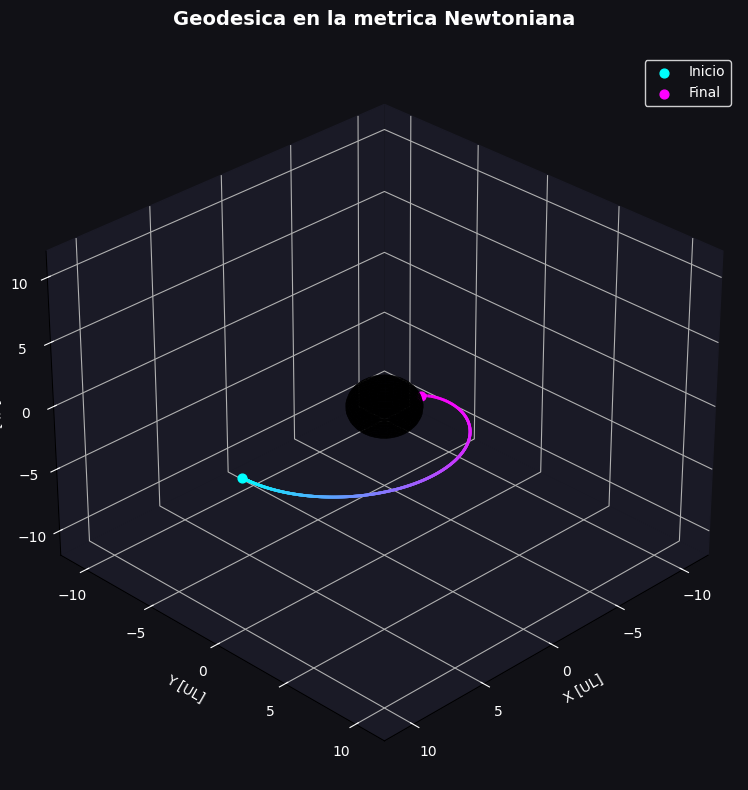

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- EXTRAER COORDENADAS DE LA PARTÍCULA DE CONTROL ---
x_p = solucion.y[1]
y_p = solucion.y[2]
z_p = solucion.y[3]
N_puntos = len(x_p)

# --- CREAR LA FIGURA 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Configuración del ángulo de visión (puedes ajustarlo a tu gusto)
ax.view_init(elev=30, azim=45)

# --- GRAFICAR LA TRAYECTORIA CON DEGRADADO (COLORMAP) ---
# Usamos un truco: graficamos pequeños segmentos para que cambien de color con el tiempo
# El color 'cool' va desde cyan (inicio) hasta magenta/rosado (final de la órbita)
cmap = plt.get_cmap('cool')
for i in range(N_puntos - 1):
    ax.plot(x_p[i:i+2], y_p[i:i+2], z_p[i:i+2], 
            color=cmap(i / N_puntos), alpha=0.8, linewidth=2.0)

# Marcamos explícitamente el punto inicial y final
ax.scatter(x_p[0], y_p[0], z_p[0], color='cyan', s=40, label='Inicio', zorder=5)
ax.scatter(x_p[-1], y_p[-1], z_p[-1], color='magenta', s=40, label='Final', zorder=5)

# --- DIBUJAR LA MASA CENTRAL (Radio de Schwarzschild como escala) ---
radio_horizonte = 2.0 * G * M / (c**2)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_bh = radio_horizonte * np.outer(np.cos(u), np.sin(v))
y_bh = radio_horizonte * np.outer(np.sin(u), np.sin(v))
z_bh = radio_horizonte * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=0.9, zorder=10)

# --- CONFIGURACIÓN ESTÉTICA EN FONDO OSCURO ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')

# Oscurecer los planos de los ejes
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

# Etiquetas de los ejes
ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

# Forzar ejes proporcionales basados en la posición inicial (con un margen)
lim = max(np.max(np.abs(x_p)), np.max(np.abs(y_p))) * 1.2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

# Título y leyenda
plt.title('Geodesica en la metrica Newtoniana', 
          color='white', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', facecolor='#111116', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

### Integración de Múltiples Partículas

Se generaliza el procedimiento anterior para un conjunto de trayectorias con condiciones iniciales distribuidas en un disco. Esto permite visualizar la estructura global del sistema y sus tendencias dinámicas.

In [7]:
#  CONFIGURACIÓN DEL DISCO 
N_particulas = 500
resultados_disco_3d = [] # Aquí guardaremos todas las órbitas

# Límites del disco: Radio interno y externo 
r_min = 5.0
r_max = 15.0



for i in range(N_particulas):
    # 1. Posición inicial aleatoria en el plano (z=0)
    r0 = np.random.uniform(r_min, r_max)
    phi = np.random.uniform(0, 2 * np.pi) 
    
    x0 = r0 * np.cos(phi)
    y0 = r0 * np.sin(phi)
    z0 = 0.0
    
    # Velocidad inicial (Órbita circular Kepleriana clásica)
    # v = sqrt(GM/r). La proyectamos perpendicular al radio vector.
    v_mag = np.sqrt(G * M / r0)
    vx0 = -v_mag * np.sin(phi)
    vy0 = v_mag * np.cos(phi)
    vz0 = 0.0
    
    # Normalización y Cuadrivelocidad inicial (documento del profesor)
    g00 = 1.0 - (2.0 * G * M) / (c**2 * r0)
    g11 = g22 = g33 = -1.0
    
    Ut0 = 1.0 / np.sqrt(g00 + g11*vx0**2 + g22*vy0**2 + g33*vz0**2)
    Ux0 = vx0 * Ut0 / c
    Uy0 = vy0 * Ut0 / c
    Uz0 = vz0 * Ut0 / c
    
    Y0 = [0.0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]
    
    # Tiempo de integración (1 órbita completa exacta por partícula usando Kepler)
    T_kepler = 2 * np.pi * np.sqrt(r0**3 / (G * M))
    # Reducimos los puntos a 200 por órbita para no saturar la memoria gráfica con 500 líneas
    taus = np.linspace(0, T_kepler, 200) 
    
    # 5. Integración numérica
    sol = solve_ivp(
        edg_newton, 
        [0.0, T_kepler], 
        Y0, 
        args=(G, M, c), 
        t_eval=taus, 
        method='Radau',
        rtol=1e-7,  # Relajamos un poco las tolerancias para hacer más rápida la ejecución masiva
        atol=1e-10
    )
    
    # Guardamos la trayectoria en la lista
    resultados_disco_3d.append(sol.y)
    


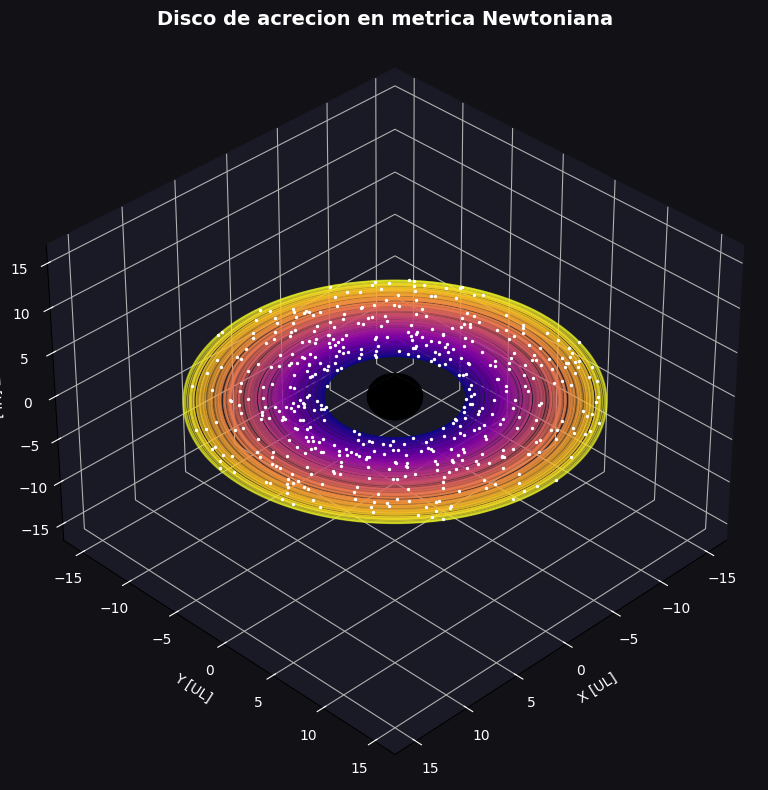

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# --- CONFIGURACIÓN DEL ÁNGULO ---
ax.view_init(elev=35, azim=45)

# --- DIBUJAR LAS 500 PARTÍCULAS ---
# Usamos un mapa de colores 'plasma' (naranja/morado) para colorearlas según su distancia
colores = cm.plasma(np.linspace(0, 1, len(resultados_disco_3d)))

for idx, y_particula in enumerate(resultados_disco_3d):
    x_p = y_particula[1]
    y_p = y_particula[2]
    z_p = y_particula[3]
    
    # Calculamos el radio promedio para darle color
    r_promedio = np.mean(np.sqrt(x_p**2 + y_p**2))
    color_asignado = cm.plasma((r_promedio - r_min) / (r_max - r_min))
    
    ax.plot(x_p, y_p, z_p, color=color_asignado, alpha=0.3, linewidth=0.8)
    ax.scatter(x_p[-1], y_p[-1], z_p[-1], color='white', s=2) # Puntos finales como "estrellas" o rocas

# --- DIBUJAR LA MASA CENTRAL ---
radio_horizonte = 2.0 * G * M / (c**2)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_bh = radio_horizonte * np.outer(np.cos(u), np.sin(v))
y_bh = radio_horizonte * np.outer(np.sin(u), np.sin(v))
z_bh = radio_horizonte * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=0.9, zorder=10)

# --- CONFIGURACIÓN ESTÉTICA ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')

ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

# Forzar ejes proporcionales
lim = r_max + 2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title('Disco de acrecion en metrica Newtoniana', 
          color='white', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Geodésicas en la Métrica de Schwarzschild

Para estudiar la dinámica de partículas en regiones donde el campo gravitacional es intenso (como las cercanías del agujero negro central en nuestro disco de acreción), la aproximación Newtoniana deja de ser válida y debemos utilizar la métrica exacta de Schwarzschild.

La métrica de Schwarzschild (bajo la signatura $+,-,-,-$) se escribe en coordenadas esféricas $(t, r, \theta, \phi)$ como:

$$
\mathrm{d}s^2 = \left(1-\frac{2GM}{c^2 r}\right) c^2 \mathrm{d}t^2 - \left(1-\frac{2GM}{c^2 r}\right)^{-1}\mathrm{d}r^2 - r^2\mathrm{d}\theta^2 - r^2\sin^2\theta \mathrm{d}\phi^2
$$

A partir de esta métrica, podemos derivar los símbolos de Christoffel que dictan las ecuaciones de la geodésica.

In [9]:
G, M, c, T, r, teta, fi = sm.symbols('G M c T r theta phi')

gmat = np.diag([1-2*G*M/(c**2*r), -1/(1-2*G*M/(c**2*r)), -r**2, -r**2*sm.sin(teta)**2])
coordenadas = T, r, teta, fi
gmet = es.MetricTensor(gmat, coordenadas)
Gab = es.ChristoffelSymbols.from_metric(gmet)
display(gmet.tensor())
display(Gab.tensor())

[[-2*G*M/(c**2*r) + 1, 0, 0, 0], [0, -1/(-2*G*M/(c**2*r) + 1), 0, 0], [0, 0, -r**2, 0], [0, 0, 0, -r**2*sin(theta)**2]]

[[[0, G*M/(r*(-2*G*M + c**2*r)), 0, 0], [G*M/(r*(-2*G*M + c**2*r)), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[-G*M*(2*G*M - c**2*r)/(c**4*r**3), 0, 0, 0], [0, G*M*(2*G*M - c**2*r)/(c**4*r**3*(-2*G*M/(c**2*r) + 1)**2), 0, 0], [0, 0, (2*G*M - c**2*r)/c**2, 0], [0, 0, 0, (2*G*M - c**2*r)*sin(theta)**2/c**2]], [[0, 0, 0, 0], [0, 0, 1/r, 0], [0, 1/r, 0, 0], [0, 0, 0, -sin(theta)*cos(theta)]], [[0, 0, 0, 0], [0, 0, 0, 1/r], [0, 0, 0, cos(theta)/sin(theta)], [0, 1/r, cos(theta)/sin(theta), 0]]]

### Ecuación de Movimiento

A partir de los símbolos de Christoffel obtenidos, construimos el sistema de ecuaciones diferenciales ordinarias de primer orden para nuestro integrador numérico. 

Siguiendo las indicaciones, a partir de este punto utilizaremos **unidades canónicas** donde $G = 1$ y $c = 1$. Esto implica que la masa $M$ define la escala de longitud y tiempo del sistema, de modo que el radio de Schwarzschild se reduce simplemente a $r_s = 2M$.

In [10]:
def edg_schwarzschild(tau, Ys, M):
    """
    Sistema de Ecuaciones Diferenciales Ordinarias para las geodésicas 
    en la métrica de Schwarzschild usando unidades donde G=1 y c=1.
    """
    # Desempaquetar el vector de estado
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys
    
    # Radio de Schwarzschild en unidades canónicas
    rs = 2 * M
    
    # 1. Derivadas de las coordenadas (es simplemente la cuadrivelocidad)
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi
    
    # 2. Derivadas de las componentes de la cuadrivelocidad (Ecuación geodésica)
    # dU^σ/dτ = - Γ^σ_{μν} U^μ U^ν
    
    # Componente t
    dUt_dtau = - (rs / (r * (r - rs))) * Ut * Ur
    
    # Componente r
    dUr_dtau = (- (rs * (r - rs) / (2 * r**3)) * Ut**2 
                + (rs / (2 * r * (r - rs))) * Ur**2 
                + (r - rs) * Utheta**2 
                + (r - rs) * np.sin(theta)**2 * Uphi**2)
    
    # Componente theta
    dUtheta_dtau = (- (2 / r) * Ur * Utheta 
                    + np.sin(theta) * np.cos(theta) * Uphi**2)
    
    # Componente phi
    dUphi_dtau = (- (2 / r) * Ur * Uphi 
                  - 2 * (np.cos(theta) / np.sin(theta)) * Utheta * Uphi)
    
    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau, 
            dUt_dtau, dUr_dtau, dUtheta_dtau, dUphi_dtau]

### Verificación rápida

Se evalúa la función con un estado de prueba para confirmar que las derivadas se calculan sin errores.

In [11]:
test_estado = [0.0, 10.0, np.pi/2, 0.0, 1.0, 0.0, 0.0, 0.1]
prueba_derivadas = edg_schwarzschild(0, test_estado, M=1.0)


prueba_derivadas

[1.0,
 0.0,
 0.0,
 0.1,
 -0.0,
 np.float64(0.07200000000000001),
 np.float64(6.123233995736767e-19),
 np.float64(-0.0)]

### Solución a las ecuaciones geodésica

Recordando que ya hemos adoptado nuestro sistema de unidades geometrizadas ($G = c = 1$) donde la masa central dicta la escala del sistema ($M = 1$), procedemos a establecer las condiciones iniciales para integrar la órbita.

A diferencia de la mecánica clásica, en Relatividad General las componentes de la velocidad inicial no son completamente arbitrarias. Para una partícula masiva, la cuadrivelocidad $U^\mu$ debe satisfacer en todo momento la condición de normalización sobre la métrica:

$$g_{\mu\nu} U^\mu U^\nu = 1$$

Dado un estado inicial de posición $(t_0, r_0, \theta_0, \phi_0)$ y unas velocidades espaciales iniciales $(U^r, U^\theta, U^\phi)$, estamos obligados a calcular la componente temporal de la cuadrivelocidad $U^t$ despejándola de la ecuación anterior. Para la métrica de Schwarzschild, esto resulta en:

$$U^t = \sqrt{\frac{1 - g_{rr}(U^r)^2 - g_{\theta\theta}(U^\theta)^2 - g_{\phi\phi}(U^\phi)^2}{g_{tt}}}$$

Con esta precaución física, garantizamos que la partícula arranque su trayectoria respetando la geometría del espacio-tiempo curvado.

### Condiciones iniciales en el espacio-tiempo

Recordando que ya hemos adoptado nuestro sistema de unidades geometrizadas ($G = 1, c = 1, M=1$), procedemos a establecer las condiciones iniciales. Para una partícula masiva, la cuadrivelocidad $U^\mu$ debe satisfacer la condición de normalización:

$$g_{\mu\nu} U^\mu U^\nu = 1$$

Dado un estado espacial inicial, despejamos la componente temporal $U^t$ para garantizar que la partícula respete la geometría del espacio-tiempo.

### Tiempos y condiciones iniciales: ¿Por cuánto tiempo integrar?
Vamos a usar la tercera ley de Kepler: $n^2 a^3 = \mu$. 
En nuestras unidades canónicas donde $\mu = M = 1$, el período orbital aproximado viene dado por $T_{kepler} = 2\pi \sqrt{r^3}$. Utilizaremos este tiempo como referencia para integrar varias órbitas y observar los efectos relativistas (como la precesión del perihelio).

In [12]:
# PARÁMETROS DEL SISTEMA 
M = 1.0             # Masa 
rs = 2.0 * M        # Radio de Schwarzschild

# POSICIÓN Y VELOCIDAD ESPACIAL INICIAL 
t0 = 0.0
r0 = 10.0 * M       # Arrancamos a 10 veces la masa de distancia
theta0 = np.pi / 2  # Plano ecuatorial 
phi0 = 0.0          # Ángulo azimutal inicial

# Velocidades iniciales 
Ur0 = 0.0           # Sin velocidad radial inicial 
Utheta0 = 0.0       # Sin movimiento vertical 
Uphi0 = 0.035       # Velocidad angular inicial.

#### Cálculo de las cuadrivelocidades iniciales

A partir de la condición de normalización, se determina `U^t` y se arma el vector de estado inicial consistente con la métrica.

In [13]:
g00 = (1.0 - rs / r0)
g11 = -1.0 / (1.0 - rs / r0)
g22 = -r0**2
g33 = -r0**2 * np.sin(theta0)**2

# Despejamos Ut garantizando que la norma sea 1 (partícula masiva)
Ut0 = np.sqrt((1.0 - (g11 * Ur0**2 + g22 * Utheta0**2 + g33 * Uphi0**2)) / g00)

# Empaquetamos el estado inicial completo
Y0 = [t0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]

#### Integración numérica

Se integra el sistema de ecuaciones usando el mismo esquema y tolerancias adoptados en las secciones anteriores.

In [14]:
T_kepler = 2.0 * np.pi * np.sqrt(r0**3 / M)

# Vamos a integrar por 3 "años" keplerianos para ver bien la órbita
tau_final = 3.0 * T_kepler  
taus = np.linspace(0, tau_final, 5000)


sol_schwarzschild = solve_ivp(
    edg_schwarzschild, 
    [0.0, tau_final], 
    Y0, 
    args=(M,), 
    t_eval=taus, 
    method='Radau', 
    rtol=1e-9,      
    atol=1e-12
)

### Extracción de la solución y Graficación

El integrador numérico nos ha devuelto la evolución del vector de estado en función del tiempo propio $\tau$. Sin embargo, las coordenadas espaciales se encuentran en formato esférico $(r, \theta, \phi)$. 

Para visualizar la trayectoria en el espacio tridimensional, debemos aplicar la transformación estándar a coordenadas cartesianas:

$$x = r \sin(\theta) \cos(\phi)$$
$$y = r \sin(\theta) \sin(\phi)$$
$$z = r \cos(\theta)$$

A continuación, extraemos estos datos, aplicamos la transformación y graficamos la órbita geodésica.

In [15]:
r_sol = sol_schwarzschild.y[1]
theta_sol = sol_schwarzschild.y[2]
phi_sol = sol_schwarzschild.y[3]

# Transformamos a cartesianas
x_sol = r_sol * np.sin(theta_sol) * np.cos(phi_sol)
y_sol = r_sol * np.sin(theta_sol) * np.sin(phi_sol)
z_sol = r_sol * np.cos(theta_sol)
N_puntos = len(x_sol)

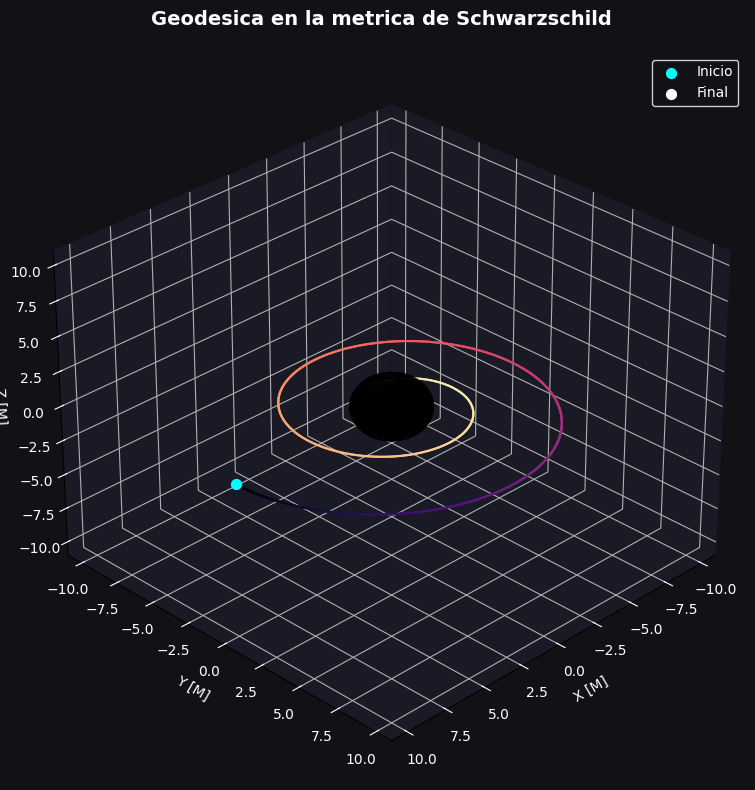

In [16]:
# --- 2. CONFIGURACIÓN DE LA FIGURA 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=30, azim=45) # Ángulo de visión

# --- 3. DIBUJAR LA GEODÉSICA (Con mapa de color temporal) ---
# Usamos un mapa de colores 'magma' para ver la evolución (de oscuro a brillante)
cmap = plt.get_cmap('magma')
for i in range(N_puntos - 1):
    ax.plot(x_sol[i:i+2], y_sol[i:i+2], z_sol[i:i+2], 
            color=cmap(i / N_puntos), alpha=0.9, linewidth=1.5)

# Puntos de inicio y fin
ax.scatter(x_sol[0], y_sol[0], z_sol[0], color='cyan', s=50, label='Inicio', zorder=5)
ax.scatter(x_sol[-1], y_sol[-1], z_sol[-1], color='white', s=50, label='Final', zorder=5)

# --- 4. DIBUJAR EL AGUJERO NEGRO (Horizonte de Eventos) ---
# En nuestras unidades, rs = 2.0 * M
rs_grafico = 2.0 * M
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_bh = rs_grafico * np.outer(np.cos(u), np.sin(v))
y_bh = rs_grafico * np.outer(np.sin(u), np.sin(v))
z_bh = rs_grafico * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=1.0, zorder=10)

# --- 5. CONFIGURACIÓN ESTÉTICA ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel('X [M]', color='white')
ax.set_ylabel('Y [M]', color='white')
ax.set_zlabel('Z [M]', color='white')
ax.tick_params(colors='white')

# Límites dinámicos para que la órbita quepa perfecta
lim = max(np.max(np.abs(x_sol)), np.max(np.abs(y_sol))) * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title('Geodesica en la metrica de Schwarzschild', 
          color='white', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', facecolor='#111116', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

### Simulación de un Disco de Acreción Relativista

Habiendo comprobado la correcta integración de una geodésica individual, procedemos a simular un ensamble estelar o disco de polvo alrededor del agujero negro. 

A diferencia del caso Newtoniano, la Relatividad General impone un límite físico estricto conocido como la Órbita Circular Estable Más Interna (ISCO). Para la métrica de Schwarzschild, la ISCO se ubica en $r = 6M$. Las partículas con radios menores a este límite no pueden mantener órbitas circulares estables y precipitan hacia el horizonte de eventos. 

Por lo tanto, distribuiremos aleatoriamente 500 partículas en el plano ecuatorial ($\theta = \pi/2$) con radios comprendidos entre $r_{min} = 6M$ y un $r_{max}$ arbitrario. Calcularemos la cuadrivelocidad temporal $U^t$ para cada una, garantizando que todo el disco respete la condición de normalización $g_{\mu\nu}U^\mu U^\nu = 1$, y visualizaremos el resultado transformando las coordenadas a un espacio cartesiano.

In [17]:
#  CONFIGURACIÓN DEL DISCO 
N_particulas = 500
M = 1.0
rs = 2.0 * M

r_min = 6.0 * M  
r_max = 20.0 * M 

# Listas para guardar las trayectorias cartesianas
resultados_x = []
resultados_y = []
resultados_z = []
radios_iniciales = []



# INTEGRACIÓN MASIVA 
for i in range(N_particulas):
    # Condiciones espaciales aleatorias
    r0 = np.random.uniform(r_min, r_max)
    phi0 = np.random.uniform(0, 2 * np.pi)
    theta0 = np.pi / 2  # Disco ecuatorial
    
    # Velocidades 
    Ur0 = 0.0
    Utheta0 = 0.0
    Uphi0 = np.sqrt(M / r0) / r0  # dphi/dtau
    
    # Cálculo de U^t para cada partícula
    g_00 = (1.0 - rs / r0)
    g_11 = -1.0 / (1.0 - rs / r0)
    g_22 = -r0**2
    g_33 = -r0**2
    
    Ut0 = np.sqrt((1.0 - (g_11*Ur0**2 + g_22*Utheta0**2 + g_33*Uphi0**2)) / g_00)
    Y0 = [0.0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]
    
    # Tiempo de integración 
    T_kepler = 2.0 * np.pi * np.sqrt(r0**3 / M)
    tau_final = 1.2 * T_kepler
    taus = np.linspace(0, tau_final, 100) # 100 puntos por partícula es suficiente
    
    # Integrador
    sol = solve_ivp(edg_schwarzschild, [0.0, tau_final], Y0, args=(M,), 
                    t_eval=taus, method='Radau', rtol=1e-5, atol=1e-8)
    
    # Extraer y transformar a cartesianas inmediatamente para no saturar memoria
    r_sol = sol.y[1]
    th_sol = sol.y[2]
    ph_sol = sol.y[3]
    
    resultados_x.append(r_sol * np.sin(th_sol) * np.cos(ph_sol))
    resultados_y.append(r_sol * np.sin(th_sol) * np.sin(ph_sol))
    resultados_z.append(r_sol * np.cos(th_sol))
    radios_iniciales.append(r0)
    


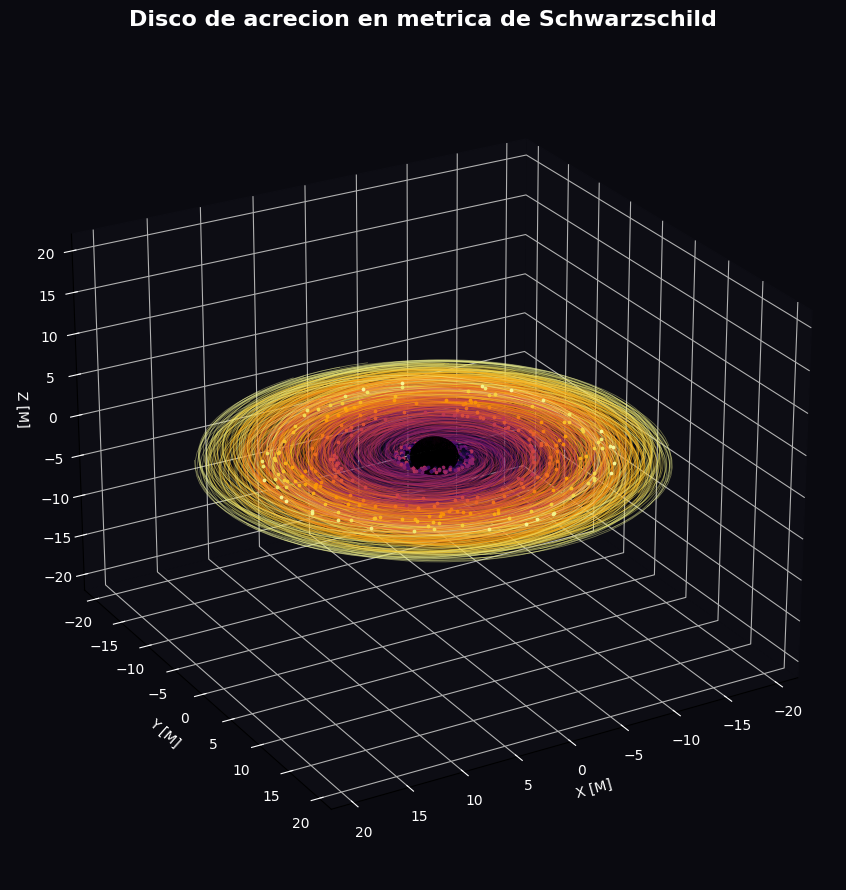

In [18]:
# --- 3. GRAFICACIÓN DEL DISCO 3D ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=25, azim=60)

# Colores basados en el radio inicial (gradiente térmico figurativo)
colores = cm.inferno((np.array(radios_iniciales) - r_min) / (r_max - r_min))

for i in range(N_particulas):
    ax.plot(resultados_x[i], resultados_y[i], resultados_z[i], 
            color=colores[i], alpha=0.4, linewidth=0.6)
    # Partícula final brillante
    ax.scatter(resultados_x[i][-1], resultados_y[i][-1], resultados_z[i][-1], 
               color=colores[i], s=3, alpha=0.9)

# Agujero Negro Central (r = 2M)
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_bh = rs * np.outer(np.cos(u), np.sin(v))
y_bh = rs * np.outer(np.sin(u), np.sin(v))
z_bh = rs * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=1.0, zorder=10)

# Estética
ax.set_facecolor('#0a0a10')
fig.patch.set_facecolor('#0a0a10')
ax.xaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.yaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.zaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))

ax.set_xlabel('X [M]', color='white')
ax.set_ylabel('Y [M]', color='white')
ax.set_zlabel('Z [M]', color='white')
ax.tick_params(colors='white')

lim = r_max * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title('Disco de acrecion en metrica de Schwarzschild', 
          color='white', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Métrica de Kerr: Agujeros Negros en Rotación

La métrica de Kerr es una solución exacta de las ecuaciones de campo de Einstein en el vacío que describe la geometría del espacio-tiempo alrededor de un cuerpo masivo, sin carga eléctrica, pero **en rotación** (con simetría axial). Dado que en el universo los objetos astrofísicos reales conservan momento angular al colapsar, la métrica de Kerr es el modelo más realista para estudiar fenómenos como los **discos de acreción** y los **jets relativistas**.

### Elemento de línea

Utilizando las **coordenadas de Boyer–Lindquist** $(t, r, \theta, \phi)$, el elemento de línea asume una forma que evita ciertas singularidades en los ejes y se expresa como:

$$ds^2 = \left(1 - \frac{R_s r}{\rho^2}\right) c^2 dt^2 + \frac{2 R_s r a \sin^2(\theta)}{\rho^2} c\, dt\, d\phi - \frac{\rho^2}{\Delta} dr^2 - \rho^2 d\theta^2 - \left( r^2 + a^2 + \frac{R_s r a^2 \sin^2(\theta)}{\rho^2} \right) \sin^2(\theta) d\phi^2$$

Donde hemos definido los siguientes parámetros y funciones auxiliares para simplificar la notación:

* **$R_s = \frac{2GM}{c^2}$**: Es el radio de Schwarzschild (relacionado con la masa $M$ del agujero negro).
* **$a = \frac{J}{Mc}$**: Es el parámetro de espín o momento angular por unidad de masa. Físicamente representa qué tan rápido rota el agujero negro.
* **$\rho^2 = r^2 + a^2 \cos^2(\theta)$**: Es una función geométrica que acopla la coordenada radial y la polar.
* **$\Delta = r^2 - R_s r + a^2$**: Es una función fundamental para determinar las singularidades coordenables (los horizontes).





In [19]:
# Definicion de los simbolos

G, M, c, t, r, theta, phi, a = sm.symbols('G M c t r theta phi a')

R_s = 2*G*M/c**2

Delta = r**2 - 2*G*M*r/c**2 + a**2
rho = r**2 + a**2 * sm.cos(theta)**2

### Componentes Geométricas de la Métrica de Kerr

Asumiendo unidades geometrizadas ($c = 1$, $G = 1$) y utilizando coordenadas de Boyer-Lindquist, los componentes covariantes del tensor métrico $g_{\mu\nu}$ se definen como:

$$
\begin{aligned}
g_{00} &= 1 - \frac{R_s r}{\rho^2} \\
g_{11} &= -\frac{\rho^2}{\Delta} \\
g_{22} &= -\rho^2 \\
g_{33} &= -\left(r^2 + a^2 + \frac{R_s r a^2 \sin^2\theta}{\rho^2}\right)\sin^2\theta \\
g_{03} &= g_{30} = \frac{R_s r a \sin^2\theta}{\rho^2}
\end{aligned}
$$

### Representación Matricial del Tensor Métrico de Kerr

En coordenadas de Boyer-Lindquist $(t, r, \theta, \phi)$ y usando unidades geometrizadas ($G=1, c=1$), el tensor métrico covariante $g_{\mu\nu}$ se puede representar como una matriz de $4 \times 4$. 

Debido a que el agujero negro es estacionario (no cambia con el tiempo) y tiene simetría axial (es simétrico respecto a su eje de rotación), muchos componentes son cero. La rotación introduce los términos cruzados fuera de la diagonal $g_{03}$ y $g_{30}$:

$$
g_{\mu\nu} = \begin{pmatrix}
g_{00} & 0 & 0 & g_{03} \\
0 & g_{11} & 0 & 0 \\
0 & 0 & g_{22} & 0 \\
g_{30} & 0 & 0 & g_{33}
\end{pmatrix}
$$

Reemplazando las expresiones geométricas correspondientes, la matriz exacta toma la siguiente forma:

$$
g_{\mu\nu} = \begin{pmatrix}
1 - \frac{R_s r}{\rho^2} & 0 & 0 & \frac{R_s r a \sin^2\theta}{\rho^2} \\
0 & -\frac{\rho^2}{\Delta} & 0 & 0 \\
0 & 0 & -\rho^2 & 0 \\
\frac{R_s r a \sin^2\theta}{\rho^2} & 0 & 0 & -\left(r^2 + a^2 + \frac{R_s r a^2 \sin^2\theta}{\rho^2}\right)\sin^2\theta
\end{pmatrix}
$$

In [20]:
g_00 = 1 - R_s * r / rho**2
g_11 = -rho**2 / Delta
g_22 = -rho**2
g_33 = - (r**2 + a**2 + R_s * r * a**2 * sm.sin(theta)**2 / rho**2) * sm.sin(theta)**2
g_03 = g_30 = R_s * r * a * sm.sin(theta)**2 / rho**2

### Representación Matricial del Tensor Métrico de Kerr

Se organiza el tensor covariante $g_{\mu\nu}$ en forma matricial para su uso en los cálculos simbólicos y numéricos posteriores.

In [21]:
g_kerr = sm.Matrix([
    [g_00, 0,    0,      g_03],
    [0,    g_11, 0,      0     ],
    [0,    0,    g_22, 0     ],
    [g_30, 0,  0,      g_33]
])

coordenadas = [t, r, theta, phi]

gmet = es.MetricTensor(g_kerr.tolist(), coordenadas)
Gab = es.ChristoffelSymbols.from_metric(gmet)

In [22]:
# Preparamos los simbolos de Christoffel para uso numerico (G=c=1).
Gamma_kerr = sm.simplify(Gab.tensor().subs({G: 1, c: 1}))
Gamma_kerr_func = sm.lambdify((r, theta, M, a), Gamma_kerr, "numpy")

def edg_kerr(tau, Ys, M_value, a_value):
    """
    Ecuaciones geodesicas para la metrica de Kerr en unidades G=c=1.
    Ys = [t, r, theta, phi, Ut, Ur, Utheta, Uphi].
    """
    t_val, r_val, theta_val, phi_val, Ut, Ur, Utheta, Uphi = Ys
    
    # Derivadas de coordenadas (cuadrivelocidad)
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi
    
    # Simbolos de Christoffel evaluados en (r, theta)
    Gamma = np.array(Gamma_kerr_func(r_val, theta_val, M_value, a_value), dtype=float)
    U = np.array([Ut, Ur, Utheta, Uphi], dtype=float)
    
    # dU^sigma/dtau = -Gamma^sigma_{mu nu} U^mu U^nu
    dU = np.zeros(4, dtype=float)
    for sigma in range(4):
        dU[sigma] = -np.sum(Gamma[sigma] * np.outer(U, U))
    
    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau,
            dU[0], dU[1], dU[2], dU[3]]

### Condiciones iniciales y normalización de la cuadrivelocidad en la Métrica de Kerr

Para simular la trayectoria de la partícula en el disco de acreción, primero debemos definir su estado inicial en el espacio-tiempo, el cual está dado por su vector de posición $x^\mu = [t, r, \theta, \phi]$ y su cuadrivelocidad $U^\mu = [U^t, U^r, U^\theta, U^\phi]$.

Trabajaremos en el **plano ecuatorial** ($\theta = \pi/2$) y usaremos unidades geometrizadas ($G=c=1$). Podemos definir libremente la posición inicial de la partícula y sus velocidades espaciales ($U^r, U^\theta, U^\phi$), pero la componente temporal de la velocidad ($U^t$) no es arbitraria. 

Por los principios de la Relatividad General, la magnitud de la cuadrivelocidad para una partícula masiva debe ser un invariante igual a $1$ (o $c^2$ en unidades convencionales):

$$g_{\mu\nu} U^\mu U^\nu = 1$$

Si expandimos esta sumatoria para la métrica de Kerr (teniendo en cuenta el término cruzado $g_{t\phi}$ que representa el arrastre del espacio-tiempo o *frame-dragging*), obtenemos:

$$g_{tt}(U^t)^2 + 2g_{t\phi}U^t U^\phi + g_{rr}(U^r)^2 + g_{\theta\theta}(U^\theta)^2 + g_{\phi\phi}(U^\phi)^2 = 1$$

Dado que conocemos todos los términos excepto $U^t$, podemos reorganizar esta expresión como una ecuación cuadrática de la forma $A(U^t)^2 + B(U^t) + C = 0$, donde los coeficientes son:

$$A = g_{tt}$$
$$B = 2 g_{t\phi} U^\phi$$
$$C = g_{rr}(U^r)^2 + g_{\theta\theta}(U^\theta)^2 + g_{\phi\phi}(U^\phi)^2 - 1$$

Para encontrar $U^t$, simplemente resolvemos la ecuación cuadrática y tomamos la raíz con el discriminante positivo ($-B + \sqrt{B^2 - 4AC}$) sobre $2A$. Esto garantiza que el tiempo propio fluya hacia el futuro, obteniendo así un vector de condiciones iniciales físicamente válido para nuestro solucionador de ecuaciones diferenciales.

In [23]:
# Condiciones iniciales para Kerr (unidades G=c=1)
M_val = 1.0
a_val = 0.5  # Espin (0 <= a <= M)

# Estado inicial en el plano ecuatorial
t0 = 0.0
r0 = 10.0 * M_val
theta0 = np.pi / 2
phi0 = 0.0

# Velocidades iniciales (puedes ajustar)
Ur0 = 0.0
Utheta0 = 0.0
Uphi0 = 0.03

# Componentes metricas de Kerr en (r0, theta0)
Rs_val = 2.0 * M_val
rho0 = r0**2 + a_val**2 * np.cos(theta0)**2
Delta0 = r0**2 - Rs_val * r0 + a_val**2

g_tt = 1.0 - Rs_val * r0 / rho0
g_rr = -rho0 / Delta0
g_thth = -rho0
g_phph = -(r0**2 + a_val**2 + (Rs_val * r0 * a_val**2 * np.sin(theta0)**2) / rho0) * np.sin(theta0)**2
g_tphi = Rs_val * r0 * a_val * np.sin(theta0)**2 / rho0

# Normalizacion: g_tt Ut^2 + 2 g_tphi Ut Uphi + g_rr Ur^2 + g_thth Utheta^2 + g_phph Uphi^2 = 1
A = g_tt
B = 2.0 * g_tphi * Uphi0
C = g_rr * Ur0**2 + g_thth * Utheta0**2 + g_phph * Uphi0**2 - 1.0

disc = B**2 - 4.0 * A * C
if disc < 0:
    raise ValueError("Discriminante negativo en la normalizacion de Ut.")

Ut0 = (-B + np.sqrt(disc)) / (2.0 * A)

Y0_kerr = [t0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]

### Integración numérica de las geodésicas en la métrica de Kerr

Se resuelve el sistema con `solve_ivp` y el método de Radau para seguir la órbita en tiempo propio manteniendo estabilidad numérica.

In [24]:
# Integracion numerica de la geodesica de Kerr
T_kepler_kerr = 2.0 * np.pi * np.sqrt(r0**3 / M_val)
tau_final_kerr = 3.0 * T_kepler_kerr
taus_kerr = np.linspace(0.0, tau_final_kerr, 5000)

sol_kerr = solve_ivp(
    edg_kerr,
    [0.0, tau_final_kerr],
    Y0_kerr,
    args=(M_val, a_val),
    t_eval=taus_kerr,
    method="Radau",
    rtol=1e-9,
    atol=1e-12
 )

### Extracción de la solución y Graficación

El integrador numérico nos ha devuelto la evolución del vector de estado en función del tiempo propio $\tau$. Sin embargo, las coordenadas espaciales se encuentran en formato esférico de Boyer-Lindquist $(r, \theta, \phi)$.

Para visualizar la trayectoria en el espacio tridimensional, debemos aplicar la transformación estándar a coordenadas cartesianas:

$$x = r \sin(\theta) \cos(\phi)$$
$$y = r \sin(\theta) \sin(\phi)$$
$$z = r \cos(\theta)$$

A continuación, extraemos estos datos, aplicamos la transformación y graficamos la órbita geodésica, incorporando una representación esférica del horizonte externo de Kerr, con radio $r_+ = M + \sqrt{M^2 - a^2}$, en el centro del sistema.

In [25]:

r_kerr = sol_kerr.y[1]
theta_kerr = sol_kerr.y[2]
phi_kerr = sol_kerr.y[3]

x_kerr = r_kerr * np.sin(theta_kerr) * np.cos(phi_kerr)
y_kerr = r_kerr * np.sin(theta_kerr) * np.sin(phi_kerr)
z_kerr = r_kerr * np.cos(theta_kerr)
N_kerr = len(x_kerr)

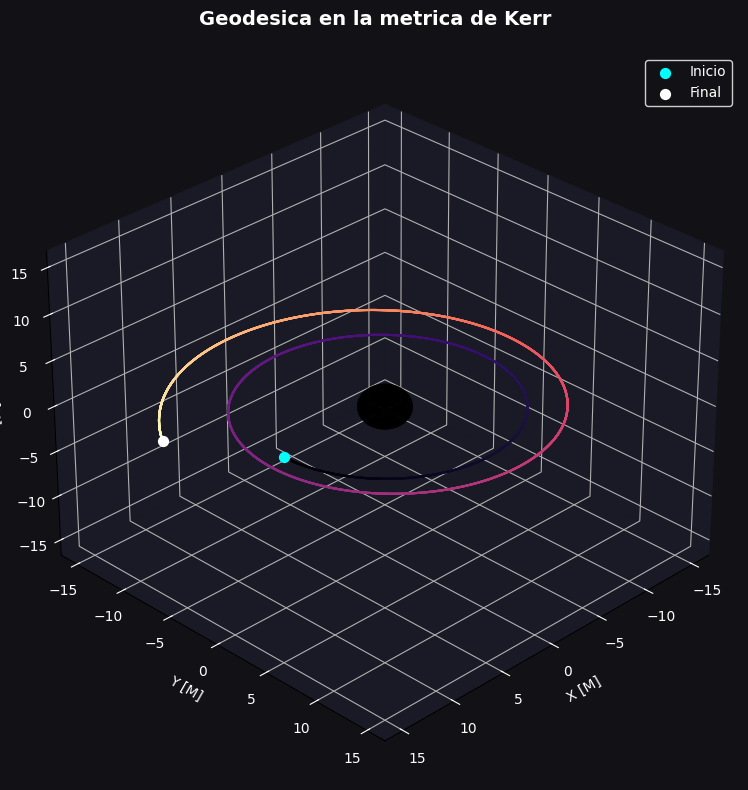

In [26]:
# Grafica 3D de la geodesica en Kerr
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(elev=30, azim=45)

cmap = plt.get_cmap("magma")
for i in range(N_kerr - 1):
    ax.plot(x_kerr[i:i+2], y_kerr[i:i+2], z_kerr[i:i+2],
            color=cmap(i / N_kerr), alpha=0.9, linewidth=1.5)

ax.scatter(x_kerr[0], y_kerr[0], z_kerr[0], color="cyan", s=50, label="Inicio", zorder=5)
ax.scatter(x_kerr[-1], y_kerr[-1], z_kerr[-1], color="white", s=50, label="Final", zorder=5)

rs_kerr = 2.0 * M_val
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_bh = rs_kerr * np.outer(np.cos(u), np.sin(v))
y_bh = rs_kerr * np.outer(np.sin(u), np.sin(v))
z_bh = rs_kerr * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_bh, y_bh, z_bh, color="black", alpha=1.0, zorder=10)

ax.set_facecolor("#111116")
fig.patch.set_facecolor("#111116")
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel("X [M]", color="white")
ax.set_ylabel("Y [M]", color="white")
ax.set_zlabel("Z [M]", color="white")
ax.tick_params(colors="white")

lim = max(np.max(np.abs(x_kerr)), np.max(np.abs(y_kerr))) * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title("Geodesica en la metrica de Kerr", color="white", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", facecolor="#111116", edgecolor="white", labelcolor="white")

plt.tight_layout()
plt.show()

In [27]:
# Integracion de 500 particulas en Kerr
N_particulas_kerr = 500
r_min_kerr = 6.0 * M_val
r_max_kerr = 20.0 * M_val

resultados_kerr_x = []
resultados_kerr_y = []
resultados_kerr_z = []
radios_kerr = []

for i in range(N_particulas_kerr):
    r0 = np.random.uniform(r_min_kerr, r_max_kerr)
    phi0 = np.random.uniform(0.0, 2.0 * np.pi)
    theta0 = np.pi / 2

    Ur0 = 0.0
    Utheta0 = 0.0
    Uphi0 = np.sqrt(M_val / r0) / r0

    Rs_val = 2.0 * M_val
    rho0 = r0**2 + a_val**2 * np.cos(theta0)**2
    Delta0 = r0**2 - Rs_val * r0 + a_val**2

    g_tt = 1.0 - Rs_val * r0 / rho0
    g_rr = -rho0 / Delta0
    g_thth = -rho0
    g_phph = -(r0**2 + a_val**2 + (Rs_val * r0 * a_val**2 * np.sin(theta0)**2) / rho0) * np.sin(theta0)**2
    g_tphi = Rs_val * r0 * a_val * np.sin(theta0)**2 / rho0

    A = g_tt
    B = 2.0 * g_tphi * Uphi0
    C = g_rr * Ur0**2 + g_thth * Utheta0**2 + g_phph * Uphi0**2 - 1.0

    disc = B**2 - 4.0 * A * C
    if disc < 0:
        continue
    Ut0 = (-B + np.sqrt(disc)) / (2.0 * A)

    Y0_part = [0.0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]

    T_kepler_part = 2.0 * np.pi * np.sqrt(r0**3 / M_val)
    tau_final_part = 1.2 * T_kepler_part
    taus_part = np.linspace(0.0, tau_final_part, 120)

    sol_part = solve_ivp(
        edg_kerr,
        [0.0, tau_final_part],
        Y0_part,
        args=(M_val, a_val),
        t_eval=taus_part,
        method="Radau",
        rtol=1e-6,
        atol=1e-9
    )

    r_part = sol_part.y[1]
    th_part = sol_part.y[2]
    ph_part = sol_part.y[3]

    resultados_kerr_x.append(r_part * np.sin(th_part) * np.cos(ph_part))
    resultados_kerr_y.append(r_part * np.sin(th_part) * np.sin(ph_part))
    resultados_kerr_z.append(r_part * np.cos(th_part))
    radios_kerr.append(r0)

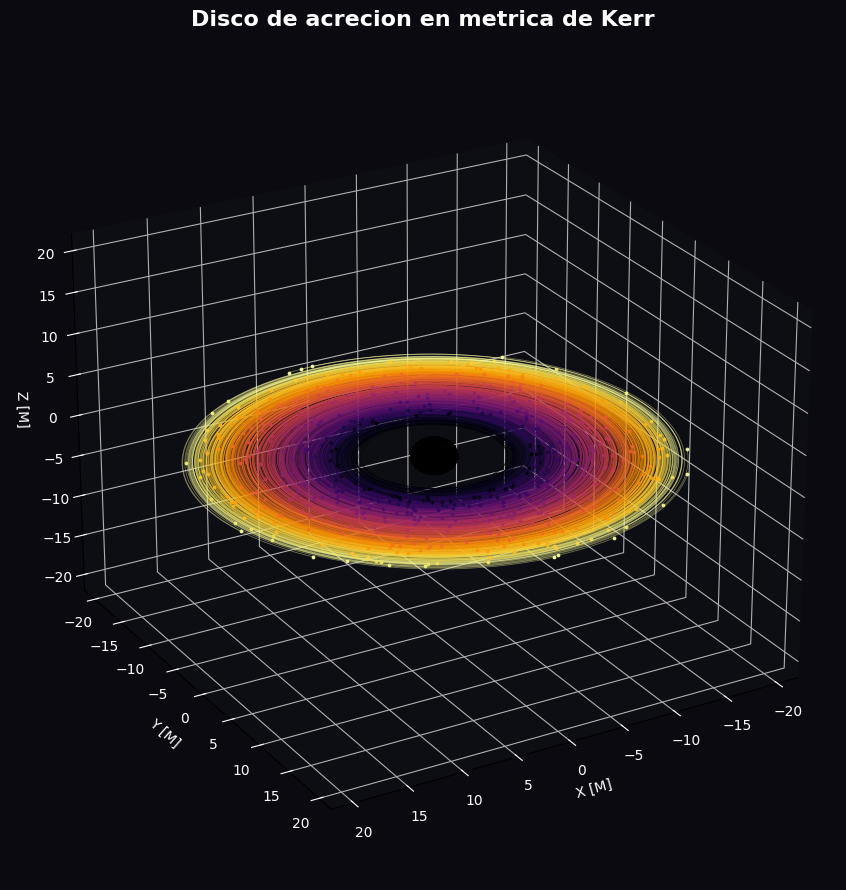

In [28]:
# Grafica 3D del disco de particulas en Kerr
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(elev=25, azim=60)

if len(radios_kerr) == 0:
    raise ValueError("No se generaron trayectorias validas para graficar.")

colores = plt.get_cmap("inferno")((np.array(radios_kerr) - r_min_kerr) / (r_max_kerr - r_min_kerr))

for i in range(len(resultados_kerr_x)):
    ax.plot(resultados_kerr_x[i], resultados_kerr_y[i], resultados_kerr_z[i],
            color=colores[i], alpha=0.4, linewidth=0.6)
    ax.scatter(resultados_kerr_x[i][-1], resultados_kerr_y[i][-1], resultados_kerr_z[i][-1],
               color=colores[i], s=3, alpha=0.9)

u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_bh = rs_kerr * np.outer(np.cos(u), np.sin(v))
y_bh = rs_kerr * np.outer(np.sin(u), np.sin(v))
z_bh = rs_kerr * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_bh, y_bh, z_bh, color="black", alpha=1.0, zorder=10)

ax.set_facecolor("#0a0a10")
fig.patch.set_facecolor("#0a0a10")
ax.xaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.yaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.zaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))

ax.set_xlabel("X [M]", color="white")
ax.set_ylabel("Y [M]", color="white")
ax.set_zlabel("Z [M]", color="white")
ax.tick_params(colors="white")

lim = r_max_kerr * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title("Disco de acrecion en metrica de Kerr", color="white", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

# Dinámica de Partículas Cargadas:  Jet Astrofísico


### Unidades Electromagnéticas Absolutas y Factores de Escala

Para integrar la fuerza electromagnética (fuerza de Lorentz) en la simulación del jet astrofísico sin introducir problemas numéricos asociados a las enormes diferencias de escala entre las magnitudes físicas reales, es conveniente expresar todas las cantidades en un sistema de unidades adimensionales definido mediante factores de escala fundamentales ($U_L$, $U_T$, $U_M$, $U_F$ y $U_Q$).

Siguiendo la idea de las **unidades electromagnéticas absolutas de Gauss**, partimos de la ley de Coulomb en el Sistema Internacional,

$$
F=\frac{q_1q_2}{4\pi\epsilon_0r^2},
$$

y buscamos un sistema computacional (denotado con prima) en el que la constante electrostática quede absorbida en la definición de las unidades, de manera que la expresión adopte la forma simplificada

$$
F'=\frac{q_1'q_2'}{r'^2}.
$$

Para ello relacionamos las cantidades físicas y computacionales mediante

$$
F=F'U_F,
\qquad
q=q'U_Q,
\qquad
r=r'U_L.
$$

Sustituyendo estas relaciones en la ley de Coulomb obtenemos

$$
F'U_F
=
\frac{(q_1'U_Q)(q_2'U_Q)}
{4\pi\epsilon_0(r'U_L)^2}
=
\left(
\frac{q_1'q_2'}{r'^2}
\right)
\frac{U_Q^2}{4\pi\epsilon_0U_L^2}.
$$

Para que la ecuación computacional tenga exactamente la forma

$$
F'=\frac{q_1'q_2'}{r'^2},
$$

es necesario que

$$
U_F
=
\frac{U_Q^2}
{4\pi\epsilon_0U_L^2},
$$

de donde se obtiene el factor de escala para la carga eléctrica

$$
\boxed{
U_Q
=
U_L
\sqrt{4\pi\epsilon_0U_F}
}.
$$

---

## Unidad del campo eléctrico ($U_E$)

El campo eléctrico se obtiene a partir de la fuerza eléctrica

$$
F=qE.
$$

Reemplazando las magnitudes físicas por sus correspondientes variables computacionales,

$$
F'U_F
=
(q'U_Q)(E'U_E),
$$

y exigiendo que en el sistema adimensional la ecuación conserve la forma

$$
F'=q'E',
$$

se obtiene inmediatamente

$$
\boxed{
U_E
=
\frac{U_F}{U_Q}
}.
$$

---

## Unidad del campo magnético ($U_B$)

Para el campo magnético partimos de la magnitud clásica de la fuerza de Lorentz,

$$
F=qvB.
$$

En el sistema computacional se adopta la velocidad de la luz como unidad fundamental de velocidad,

$$
U_V=c,
$$

de modo que cualquier velocidad física puede escribirse como

$$
v=v'c,
$$

donde $v'$ es una cantidad adimensional.

Sustituyendo las correspondientes relaciones de escala,

$$
F'U_F
=
(q'U_Q)(v'c)(B'U_B),
$$

obtenemos

$$
F'U_F
=
(q'v'B')
(U_QcU_B).
$$

Para que la ecuación computacional conserve la forma

$$
F'=q'v'B',
$$

debe cumplirse

$$
U_F
=
U_QcU_B,
$$

por lo que

$$
\boxed{
U_B
=
\frac{U_F}{U_Qc}
=
\frac{U_E}{c}
}.
$$

---

## Observación sobre las unidades relativistas

Es importante señalar que, si posteriormente la simulación se formula utilizando **unidades relativistas** ($c=1$), como es habitual en relatividad general y en la formulación covariante del tensor de Faraday,

$$
F_{\mu\nu},
$$

los campos eléctrico y magnético poseen las mismas dimensiones físicas. En ese caso,

$$
\boxed{
U_B=U_E,
}
$$

ya que el factor $c$ queda absorbido por la elección de unidades naturales.

Por ello, la expresión

$$
U_B=\frac{U_E}{c}
$$

es válida cuando se trabaja en unidades SI, mientras que en una implementación completamente relativista con $c=1$ ambas unidades coinciden.

---

Con estos factores de escala completamente definidos, cualquier magnitud electromagnética del entorno del agujero negro (como la carga elemental, la masa del electrón o la intensidad del campo magnético externo) puede transformarse a variables adimensionales dividiéndola por su correspondiente unidad fundamental. Esto permite implementar la fuerza de Lorentz y el tensor de Faraday de forma numéricamente estable, evitando errores asociados a la manipulación de magnitudes extremadamente grandes o pequeñas.

In [29]:
c_SI = const.c                  # Velocidad de la luz [m/s]
eps0_SI = const.eps0      # Permitividad del vacío [F/m]
m_e_SI = const.m_e              # Masa del electrón [kg]
e_SI = const.e                  # Carga elemental [C]



# Unidad de masa: masa del electrón
UM = m_e_SI

# Unidad característica de longitud
# (100 km alrededor del agujero negro)
UL = 100e3                      # [m]

# En unidades relativistas la velocidad de referencia es c
UV = c_SI

# Unidad de tiempo
UT = UL / UV

# 2. Unidades mecánicas derivadas


# Unidad de aceleración
UA = UV**2 / UL

# Unidad de fuerza
UF = UM * UA

# 3. Unidades electromagnéticas

# Unidad de carga
UQ = UL * np.sqrt(4.0 * np.pi * eps0_SI * UF)

# Unidad de campo eléctrico
UE = UF / UQ

UB = UE



# 4. Propiedades adimensionales de la partícula


# Masa del electrón
m_sim_e = m_e_SI / UM

# Carga del electrón (con signo físico)
q_sim_e = -e_SI / UQ



# 5. Constantes relativistas del código


# Velocidad de la luz en unidades computacionales
C = 1.0




## El modelo del campo electromagnético en el Jet AstrofísicoLos 

Los jets astrofísicos son enormes chorros de plasma (partículas cargadas) que son expulsados a velocidades relativistas desde las cercanías de un agujero negro. Para simular la dinámica de estas partículas, primero debemos establecer el entorno electromagnético por el cual se desplazan.

En nuestro modelo inicial, asumiremos que el jet está dominado por un campo magnético helicoidal, el cual es una aproximación estándar y muy útil para describir estos fenómenos. En coordenadas cilíndricas $(r, \phi, z)$, este campo se describe mediante las siguientes componentes:
$$B_r = 0$$
$$B_z = B_0$$
$$B_\phi = \frac{B_1}{r}$$

Donde $B_0$ representa la componente longitudinal constante a lo largo del eje del jet y $B_1$ controla la intensidad del campo toroidal que decae con la distancia radial $r$.

Para poder integrar las ecuaciones de movimiento usando el cuadrimomentum o la ecuación de la fuerza de Lorentz covariante, nos resultará mucho más conveniente trabajar en coordenadas cartesianas $(x, y, z)$. La transformación de las componentes del campo magnético es:

$$B_x = B_r \cos\phi - B_\phi \sin\phi = - \left(\frac{B_1}{\sqrt{x^2+y^2}}\right) \left(\frac{y}{\sqrt{x^2+y^2}}\right) = -B_1 \frac{y}{x^2+y^2}$$
$$B_y = B_r \sin\phi + B_\phi \cos\phi = \left(\frac{B_1}{\sqrt{x^2+y^2}}\right) \left(\frac{x}{\sqrt{x^2+y^2}}\right) = B_1 \frac{x}{x^2+y^2}$$
$$B_z = B_0$$
Con estas componentes del campo magnético, y asumiendo por el momento que no hay campo eléctrico externo externo ($\vec{E} = 0$), podemos proceder a ensamblar el Tensor de Faraday $F^{\mu \nu}$ que dictará el movimiento de nuestras partículas a través de la ecuación geodésica modificada (Ecuación de Lorentz covariante).

## El Tensor de Faraday ($F^{\mu\nu}$)

En relatividad, los campos eléctrico ($\vec{E}$) y magnético ($\vec{B}$) no son entidades separadas, sino que son simplemente las componentes de un único objeto geométrico de segundo rango: el Tensor de Faraday o Tensor de Campo Electromagnético.Para poder introducir el campo magnético del jet en las ecuaciones de movimiento covariantes, debemos ensamblar este tensor. En coordenadas cartesianas $(t, x, y, z)$ y asumiendo unidades naturales ($c=1$), las componentes contravariantes del Tensor de Faraday $F^{\mu\nu}$ se organizan en una matriz antisimétrica $4 \times 4$ de la siguiente manera:$$F^{\mu\nu} = \begin{pmatrix}
0 & -E_x & -E_y & -E_z \\
E_x & 0 & B_z & -B_y \\
E_y & -B_z & 0 & B_x \\
E_z & B_y & -B_x & 0
\end{pmatrix}$$Dado que en nuestro modelo inicial del jet astrofísico estamos asumiendo que no hay un campo eléctrico externo ($\vec{E} = 0$), las componentes temporales ($F^{0i}$ y $F^{i0}$) serán cero. Las componentes puramente espaciales ($F^{ij}$) contendrán el campo magnético helicoidal que calculamos previamente:$$F^{\mu\nu} = \begin{pmatrix}
0 & 0 & 0 & 0 \\
0 & 0 & B_0 & -B_1 \frac{x}{x^2+y^2} \\
0 & -B_0 & 0 & -B_1 \frac{y}{x^2+y^2} \\
0 & B_1 \frac{x}{x^2+y^2} & B_1 \frac{y}{x^2+y^2} & 0
\end{pmatrix}$$Esta es exactamente la matriz que calcularemos computacionalmente en cada punto de la trayectoria de la partícula para evaluar la fuerza que experimenta.

In [34]:
B0 = 1.0  # Intensidad del campo magnético longitudinal (en el eje z)
B1 = 1.0  # Constante de intensidad del campo magnético toroidal

def tensor_faraday(x_L):
    """
    Calcula el Tensor de Faraday F^{mu nu} (contravariante) en coordenadas 
    cartesianas para un campo magnético helicoidal.
    
    Parámetros:
    x_L : array-like
        Arreglo con las coordenadas espaciotemporales [t, x, y, z]
        
    Retorna:
    F : numpy.ndarray (4x4)
        Matriz antisimétrica representando F^{mu nu}
    """
    t, x, y, z = x_L
    
    # Evitamos la singularidad matemática justo en el centro del jet (r=0)
    # sumando un epsilon muy pequeño al radio al cuadrado.
    r2 = x**2 + y**2 + 1e-12
    
    # Ecuaciones de las componentes espaciales del campo magnético
    Bx = -B1 * y / r2
    By = B1 * x / r2
    Bz = B0
    
    # Asumimos un campo eléctrico nulo en el sistema del jet
    Ex, Ey, Ez = 0.0, 0.0, 0.0
    
    # Inicializamos el Tensor de Faraday (matriz 4x4 llena de ceros)
    # Asumimos unidades naturales/relativistas donde c=1
    F = np.zeros((4, 4))
    
    # Llenamos las componentes correspondientes al campo eléctrico (F^{0i} y F^{i0})
    F[0, 1], F[0, 2], F[0, 3] = -Ex, -Ey, -Ez
    F[1, 0], F[2, 0], F[3, 0] = Ex, Ey, Ez
    
    # Llenamos las componentes correspondientes al campo magnético (F^{ij})
    F[1, 2] = Bz
    F[1, 3] = -By
    F[2, 1] = -Bz
    F[2, 3] = Bx
    F[3, 1] = By
    F[3, 2] = -Bx
    
    return F

# ====================================================================
# PRUEBA DE LA FUNCIÓN
# ====================================================================
punto_prueba = np.array([0.0, 1.0, 0.0, 0.0]) # Un punto en el eje x (t=0, x=1, y=0, z=0)
F_prueba = tensor_faraday(punto_prueba)

print("Tensor de Faraday F^{mu nu} en el punto (t=0, x=1, y=0, z=0):\n")
print(np.round(F_prueba, 2))

Tensor de Faraday F^{mu nu} en el punto (t=0, x=1, y=0, z=0):

[[ 0. -0. -0. -0.]
 [ 0.  0.  1. -1.]
 [ 0. -1.  0. -0.]
 [ 0.  1.  0.  0.]]


## Ecuación de Movimiento: La Fuerza de Lorentz Covariante

Una vez definido el entorno electromagnético mediante el Tensor de Faraday ($F^{\mu\nu}$), necesitamos determinar cómo este campo altera la trayectoria de nuestra partícula cargada (por ejemplo, un electrón o un protón del plasma).

En la física clásica, esto se describe mediante la fuerza de Lorentz ($\vec{F} = q(\vec{E} + \vec{v} \times \vec{B})$). En el marco de la relatividad, esta ley se generaliza a una forma tensorial y manifiestamente covariante, conocida como la Fuerza de Lorentz Covariante:

$$m \frac{dU^\mu}{d\tau} = q F^{\mu}_{\ \ \nu} U^\nu$$

Donde:$m$ es la masa en reposo de la partícula.$q$ es la carga de la partícula.$U^\mu = \frac{dx^\mu}{d\tau}$ es la cuadrivelocidad contravariante.$\tau$ es el tiempo propio de la partícula.Dado que en nuestra celda anterior construimos el tensor totalmente contravariante $F^{\mu\nu}$, resulta más conveniente escribir la ecuación utilizando la métrica del espacio-tiempo para bajar el índice de la cuadrivelocidad. Si por el momento nos enfocamos puramente en la dinámica electromagnética del jet (asumiendo un espacio-tiempo plano de Minkowski, $\eta_{\mu\nu}$), la ecuación se expresa como:

$$\frac{dU^\mu}{d\tau} = \frac{q}{m} F^{\mu\nu} \eta_{\nu\alpha} U^\alpha$$

Para simular la trayectoria de la partícula en Python, no basta con calcular la aceleración; debemos resolver el sistema completo acoplando la cinemática a la dinámica. Esto se traduce en un sistema de 8 ecuaciones diferenciales ordinarias (EDOs) de primer orden (4 para la posición y 4 para la cuadrivelocidad) que evolucionan respecto al tiempo propio $\tau$:Ecuación cinemática (variación de la posición espaciotemporal):$$\frac{dx^\mu}{d\tau} = U^\mu$$Ecuación dinámica (variación de la cuadrivelocidad por la fuerza de Lorentz):$$\frac{dU^\mu}{d\tau} = \left(\frac{q}{m}\right) F^{\mu\nu} U_\nu$$Al integrar computacionalmente este sistema desde un evento inicial $(t_0, x_0, y_0, z_0)$ con una cuadrivelocidad inicial $U^\mu_0$, obtendremos la línea de universo completa de la partícula a través del jet astrofísico.

In [35]:
eta = np.diag([1.0, -1.0, -1.0, -1.0])


q_m = -1.0 

def ecuaciones_movimiento(tau, estado):
    """
    Sistema de Ecuaciones Diferenciales Ordinarias (EDOs) para la partícula en el jet.
    Calcula la variación de la posición y la cuadrivelocidad respecto al tiempo propio tau.
    
    Parámetros:
    tau : float
        Tiempo propio actual de la partícula (variable independiente).
    estado : array-like (tamaño 8)
        Vector de estado con las posiciones y cuadrivelocidades actuales: 
        [t, x, y, z, U^t, U^x, U^y, U^z]
        
    Retorna:
    derivadas : numpy.ndarray (tamaño 8)
        Arreglo con [dx^mu/dtau, dU^mu/dtau]
    """
    # Desempaquetamos el estado actual
    x_L = estado[0:4]             # Cuadriposición: x^mu = [t, x, y, z]
    U_contra = estado[4:8]        # Cuadrivelocidad contravariante: U^mu = [U^t, U^x, U^y, U^z]
    
    # ---------------------------------------------------------
    # 1. Ecuación Cinemática: dx^mu / dtau = U^mu
    # ---------------------------------------------------------
    dx_dtau = U_contra
    
    # ---------------------------------------------------------
    # 2. Ecuación Dinámica: dU^mu / dtau = (q/m) * F^{mu nu} * eta_{nu alpha} * U^alpha
    # ---------------------------------------------------------
    
    # a) Obtenemos el Tensor de Faraday F^{mu nu} en la posición actual
    F_contra = tensor_faraday(x_L)
    
    # b) Bajamos el índice de la cuadrivelocidad usando la métrica de Minkowski
    # U_nu = eta_{nu alpha} U^alpha
    # Esto equivale a hacer un producto matricial: [eta] * [U]
    U_cova = np.dot(eta, U_contra) 
    
    # c) Calculamos la aceleración por la Fuerza de Lorentz
    # (q/m) * F^{mu nu} * U_nu
    # np.dot(F_contra, U_cova) realiza la contracción del índice 'nu'
    dU_dtau = q_m * np.dot(F_contra, U_cova)
    
    # ---------------------------------------------------------
    # Retornamos el vector con todas las derivadas concatenadas
    # ---------------------------------------------------------
    return np.concatenate((dx_dtau, dU_dtau))

# ====================================================================
# PRUEBA RÁPIDA DE LAS ECUACIONES
# ====================================================================
estado_inicial_prueba = np.array([0.0, 1.0, 0.0, 0.0,  # [t, x, y, z] inicial
                                  1.0, 0.0, 0.1, 0.5]) # [U^t, U^x, U^y, U^z] inicial

derivadas_prueba = ecuaciones_movimiento(0.0, estado_inicial_prueba)

print("Derivadas calculadas en el instante inicial [dx^mu/dtau, dU^mu/dtau]:")
print(np.round(derivadas_prueba, 3))

Derivadas calculadas en el instante inicial [dx^mu/dtau, dU^mu/dtau]:
[ 1.   0.   0.1  0.5 -0.  -0.4 -0.  -0. ]


In [36]:
# --- CONDICIONES INICIALES DE LA PARTÍCULA EN EL JET ---

t0 = 0.0
x0, y0, z0 = 2.0, 0.0, 0.0   # Posición inicial: ligeramente fuera del eje del jet (eje z)

# Velocidad espacial inicial (en unidades de c)
vx0, vy0, vz0 = 0.05, 0.0, 0.8   # Movimiento dominante a lo largo del eje del jet (z)

v2 = vx0**2 + vy0**2 + vz0**2
if v2 >= 1.0:
    raise ValueError("La velocidad espacial inicial debe ser menor que c (|v|^2 < 1).")

# Factor de Lorentz inicial
gamma0 = 1.0 / np.sqrt(1.0 - v2)

# Componentes de la cuadrivelocidad inicial
Ut0 = gamma0
Ux0 = gamma0 * vx0
Uy0 = gamma0 * vy0
Uz0 = gamma0 * vz0

# Vector de estado inicial: [t, x, y, z, U^t, U^x, U^y, U^z]
Y0_jet = [t0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]

# Verificación de la normalización: eta_mu_nu U^mu U^nu debe dar 1
norma = Ut0**2 - Ux0**2 - Uy0**2 - Uz0**2
print(f"Verificación eta_mu_nu U^mu U^nu = {norma:.6f}")

Verificación eta_mu_nu U^mu U^nu = 1.000000


In [37]:
# --- TIEMPO DE INTEGRACIÓN ---

delta_z = 80.0          # Distancia a recorrer a lo largo del eje del jet (en UL)
tau_final = delta_z / vz0
taus = np.linspace(0.0, tau_final, 4000)

# --- INTEGRACIÓN NUMÉRICA ---

sol_jet = solve_ivp(
    ecuaciones_movimiento,
    [0.0, tau_final],
    Y0_jet,
    t_eval=taus,
    method='Radau',
    rtol=1e-9,
    atol=1e-12
)

print(sol_jet.status, sol_jet.message)


0 The solver successfully reached the end of the integration interval.


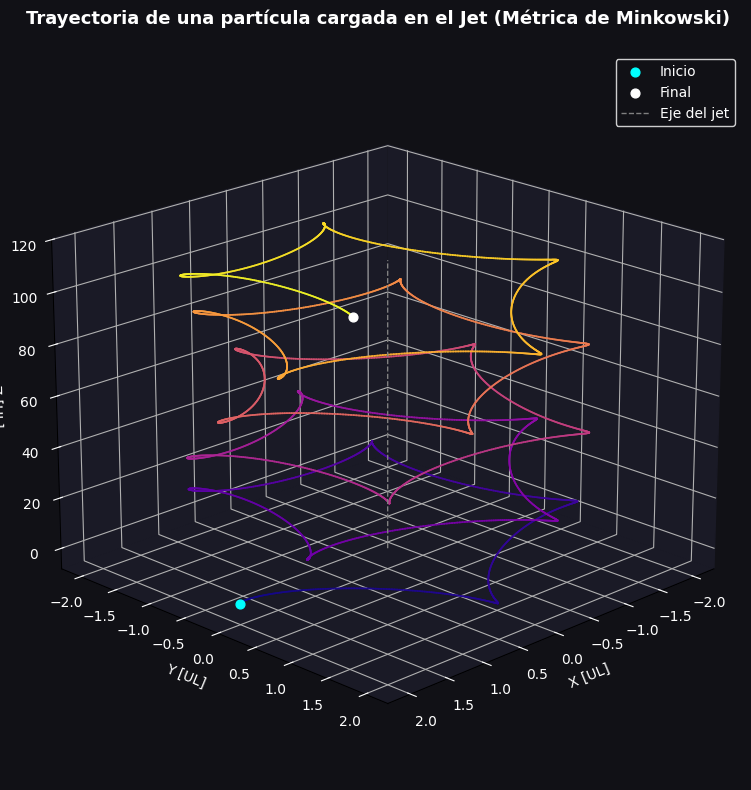

In [38]:
x_jet = sol_jet.y[1]
y_jet = sol_jet.y[2]
z_jet = sol_jet.y[3]
N_jet = len(x_jet)

# --- GRÁFICA 3D DE LA TRAYECTORIA EN EL JET ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=20, azim=45)

# Mapa de color a lo largo de la trayectoria (evolución temporal)
cmap = plt.get_cmap('plasma')
for i in range(N_jet - 1):
    ax.plot(x_jet[i:i+2], y_jet[i:i+2], z_jet[i:i+2],
            color=cmap(i / N_jet), alpha=0.9, linewidth=1.2)

# Puntos de inicio y fin
ax.scatter(x_jet[0], y_jet[0], z_jet[0], color='cyan', s=40, label='Inicio', zorder=5)
ax.scatter(x_jet[-1], y_jet[-1], z_jet[-1], color='white', s=40, label='Final', zorder=5)

# Eje del jet (eje z) como referencia visual
ax.plot([0, 0], [0, 0], [z_jet.min(), z_jet.max()],
        color='gray', linestyle='--', linewidth=1, label='Eje del jet')

# --- CONFIGURACIÓN ESTÉTICA (mismo estilo que las secciones anteriores) ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

plt.title('Trayectoria de una partícula cargada en el Jet (Métrica de Minkowski)',
          color='white', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', facecolor='#111116', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

In [40]:
# --- CONFIGURACIÓN DEL JET: 100 PARTÍCULAS ---
np.random.seed(0)
N_particulas_jet = 100

# Posición inicial: anillo alrededor del eje del jet, en z=0
r_jet_min = 0.5
r_jet_max = 3.0

# Velocidad de propagación a lo largo del jet (con dispersión)
vz_min, vz_max = 0.7, 0.9

# Dispersión transversal inicial (movimiento de giro)
vt_max = 0.05

delta_z = 80.0  # distancia a recorrer a lo largo del eje del jet (en UL)

resultados_jet_x = []
resultados_jet_y = []
resultados_jet_z = []
radios_jet = []

for i in range(N_particulas_jet):
    # Posición inicial aleatoria en un anillo alrededor del eje z
    r0 = np.random.uniform(r_jet_min, r_jet_max)
    phi0 = np.random.uniform(0, 2 * np.pi)
    x0 = r0 * np.cos(phi0)
    y0 = r0 * np.sin(phi0)
    z0 = 0.0

    # Velocidad espacial inicial (dominada por v^z, con dispersión transversal)
    vz0 = np.random.uniform(vz_min, vz_max)
    vx0 = np.random.uniform(-vt_max, vt_max)
    vy0 = np.random.uniform(-vt_max, vt_max)

    v2 = vx0**2 + vy0**2 + vz0**2
    if v2 >= 1.0:
        continue  # descartamos por seguridad si |v| >= c

    # Normalización de la cuadrivelocidad
    gamma0 = 1.0 / np.sqrt(1.0 - v2)
    Y0_part = [0.0, x0, y0, z0, gamma0, gamma0*vx0, gamma0*vy0, gamma0*vz0]

    # Tiempo propio de integración (escala con v^z de cada partícula)
    tau_final_part = delta_z / vz0
    taus_part = np.linspace(0.0, tau_final_part, 300)

    sol_part = solve_ivp(
        ecuaciones_movimiento,
        [0.0, tau_final_part],
        Y0_part,
        t_eval=taus_part,
        method='Radau',
        rtol=1e-7,
        atol=1e-10
    )

    # Coordenadas ya son cartesianas en Minkowski: se guardan directamente
    resultados_jet_x.append(sol_part.y[1])
    resultados_jet_y.append(sol_part.y[2])
    resultados_jet_z.append(sol_part.y[3])
    radios_jet.append(r0)

c:\Users\User\OneDrive\Documentos\Relatividad\.venv\Lib\site-packages\scipy\integrate\_ivp\common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
c:\Users\User\OneDrive\Documentos\Relatividad\.venv\Lib\site-packages\scipy\integrate\_ivp\common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
c:\Users\User\OneDrive\Documentos\Relatividad\.venv\Lib\site-packages\scipy\integrate\_ivp\common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
c:\Users\User\OneDrive\Documentos\Relatividad\.venv\Lib\site-packages\scipy\integrate\_ivp\common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


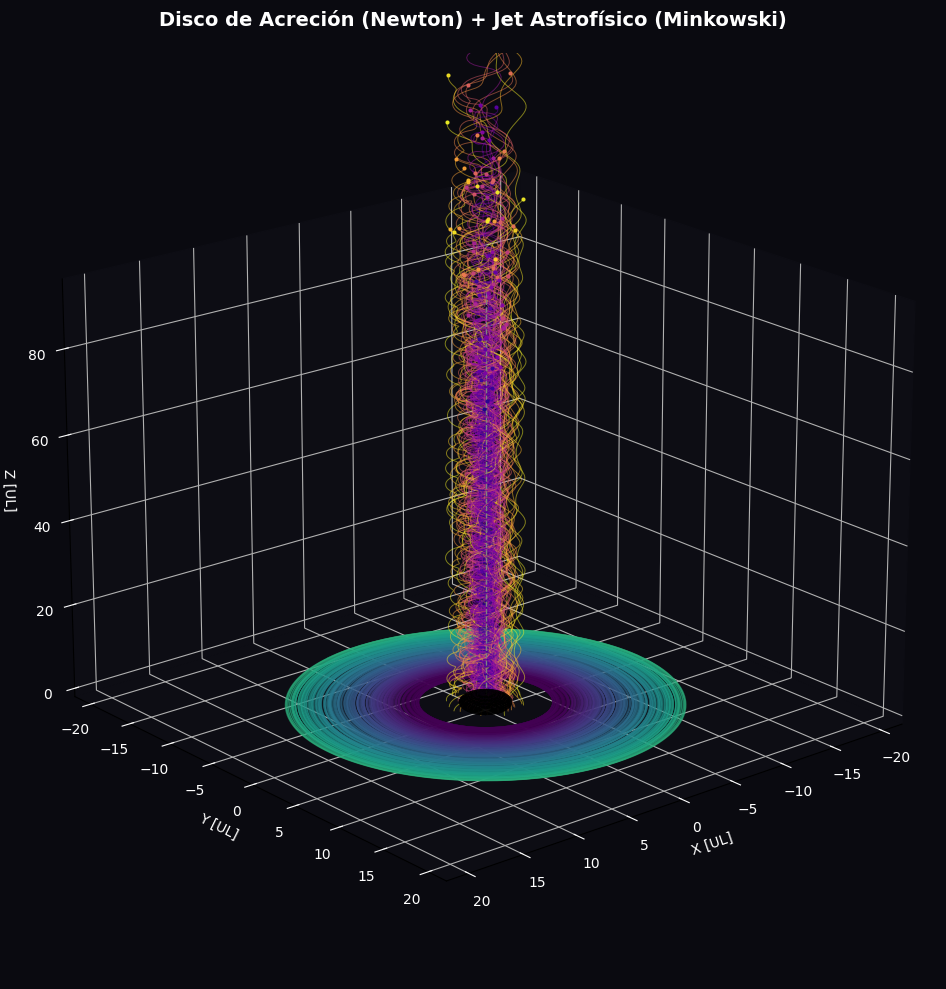

In [43]:
# --- GRÁFICA COMBINADA: DISCO DE ACRECIÓN (NEWTON) + JET (MINKOWSKI) ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=20, azim=50)

# --- DISCO DE ACRECIÓN ---
for idx, y_particula in enumerate(resultados_disco_3d):
    x_p, y_p, z_p = y_particula[1], y_particula[2], y_particula[3]
    r_prom = np.mean(np.sqrt(x_p**2 + y_p**2))
    color_disco = cm.viridis((r_prom - r_min) / (r_max - r_min))
    ax.plot(x_p, y_p, z_p, color=color_disco, alpha=0.35, linewidth=0.8)

# --- JET ASTROFÍSICO ---
colores_jet = cm.plasma((np.array(radios_jet) - r_jet_min) / (r_jet_max - r_jet_min))
for i in range(len(resultados_jet_x)):
    ax.plot(resultados_jet_x[i], resultados_jet_y[i], resultados_jet_z[i],
            color=colores_jet[i], alpha=0.5, linewidth=0.7)
    ax.scatter(resultados_jet_x[i][-1], resultados_jet_y[i][-1], resultados_jet_z[i][-1],
               color=colores_jet[i], s=4, alpha=0.9)

# --- AGUJERO NEGRO CENTRAL ---
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
rs_central = 2.0  # Radio de Schwarzschild (M=1)
x_bh = rs_central * np.outer(np.cos(u), np.sin(v))
y_bh = rs_central * np.outer(np.sin(u), np.sin(v))
z_bh = rs_central * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=1.0, zorder=10)

# Eje del jet (referencia visual)
ax.plot([0, 0], [0, 0], [0, delta_z * 1.2], color='gray', linestyle='--', linewidth=1)

# --- ESTÉTICA ---
ax.set_facecolor('#0a0a10')
fig.patch.set_facecolor('#0a0a10')
ax.xaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.yaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.zaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))

ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

lim_xy = r_max * 1.1
ax.set_xlim(-lim_xy, lim_xy)
ax.set_ylim(-lim_xy, lim_xy)
ax.set_zlim(-2, delta_z * 1.2)

plt.title('Disco de Acreción (Newton) + Jet Astrofísico (Minkowski)',
          color='white', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Prompts para la ayuda de la IA 


1. en la celda de texto tengo la teoria, con ecuaciones que usea para escribir codigo en python, puedes ayudarme a hacer una mejor redacción

2. para cada una de las metricas yo ya hice la simulacion para una sola particula, puedes ayudarme a crear la simulacion para multiples particulas 

3. ayudame a comentar la celdas codigo, ya que he ido escribiendo y se me ha olvidado escribir los comentarios 

4. ayudame a corregir el error que tengo en la ecuacion de Kerr pues me arroja un error y no lo he podido encontrar 

5. en la simulacion del Jet estoy teniendoun error en el calculo de los simbolos de christofell puedes ayudarme a corregirlo 
